# Experiment 3: Compaction

## The problem
Some tasks need their history -- you can't just truncate it away (Exp 2). But
history that grows unbounded eventually overflows the context window and the
task dies.

## The fix
Compaction: when context nears its limit, summarize the conversation so far
(MAXIMIZE RECALL FIRST, then precision -- Section 8.1), replace the raw history
with the summary, and keep going.

## Method
A running-synthesis task: read papers one by one, keep a running theme list.
Naive lets history grow until it overflows a small window. Engineered compacts
at a threshold and finishes -- producing the "sawtooth" token curve.

## Research doc references
Section 8.1 (Compaction) - Section 9 (long-horizon work past the window limit)

## Setup

In [1]:
import json, os, sys, time
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
MODEL_ID = os.getenv("BEDROCK_MODEL_ID", "us.anthropic.claude-3-5-haiku-20241022-v1:0")
REGION   = os.getenv("AWS_REGION", "us-east-1")
INDEX = json.loads((PROJECT_ROOT / "data" / "index.json").read_text())
print(INDEX)
print(MODEL_ID, "@", REGION, "|", len(INDEX), "papers")

[{'id': '1706.03762', 'title': 'Attention Is All You Need', 'desc': 'transformer architecture; self-attention; attention scores sum to 1.0', 'path': 'data/corpus/1706.03762.txt'}, {'id': '2307.03172', 'title': 'Lost in the Middle', 'desc': 'how LLMs use long contexts; U-shaped position performance curve', 'path': 'data/corpus/2307.03172.txt'}, {'id': '2404.06654', 'title': 'RULER', 'desc': 'measuring the real effective context length of long-context models', 'path': 'data/corpus/2404.06654.txt'}, {'id': '2005.11401', 'title': 'Retrieval-Augmented Generation', 'desc': 'RAG for knowledge-intensive NLP tasks', 'path': 'data/corpus/2005.11401.txt'}, {'id': '2311.05232', 'title': 'A Survey on Hallucination in LLMs', 'desc': 'taxonomy of hallucination including factuality vs faithfulness', 'path': 'data/corpus/2311.05232.txt'}, {'id': '2302.12173', 'title': 'Indirect Prompt Injection', 'desc': 'compromising LLM apps via malicious instructions in retrieved data', 'path': 'data/corpus/2302.121

In [3]:
# Deliberately SMALL window so overflow happens fast and visibly (a demo
# budget, NOT a real 200k window).
MAX_TOKENS = 6000
COMPACTION_THRESHOLD = 0.8        # compact when tokens > 0.8 * MAX_TOKENS
PER_PAPER_TOKENS = 1200           # how much of each paper we feed per step
TASK = ("Read each paper in turn. After each, update a running list of the key "
        "themes across all papers read so far. Output ONLY the theme list.")
print("window:", MAX_TOKENS, "| compact at:", int(COMPACTION_THRESHOLD*MAX_TOKENS))

window: 6000 | compact at: 4800


## The pieces we need

In [4]:
from core.tokenizer import count_tokens
from tools.load_document import load_document
import boto3
bedrock = boto3.client("bedrock-runtime", region_name=REGION)

def user(text):     
     return {"role": "user", "content": [{"text": text}]}
def assistant(text): 
     return {"role": "assistant", "content": [{"text": text}]}
def messages_text(msgs): 
     return " ".join(b["text"] for m in msgs for b in m["content"])

In [5]:
msg = [{'role': 'user', 'content': [{'text': 'Paper \n\n\nUpdate the running theme list.'}]}]
def messages_text(msgs): 
     return " ".join(b["text"] for m in msgs for b in m["content"])

print(messages_text(msgs=msg))

Paper 


Update the running theme list.


In [6]:
TOKENS_PER_WORD = 2.05
def truncate_to_tokens(text, max_tokens):
    max_words = max(1, int(max_tokens / TOKENS_PER_WORD))
    words = text.split()
    return text if len(words) <= max_words else " ".join(words[:max_words]) + " [...]"

def ask(system, messages, max_out=300):
    """One Converse call. Returns (answer, real_input_tokens)."""
    resp = bedrock.converse(modelId=MODEL_ID, system=[{"text": system}],
                            messages=messages,
                            inferenceConfig={"maxTokens": max_out, "temperature": 0.0})
    return resp["output"]["message"]["content"][0]["text"], resp["usage"]["inputTokens"]

## The compaction step

Recall-first: keep decisions, the running theme list, open steps, key facts.
Drop redundant raw text. The summary REPLACES the raw history.

In [7]:
def compact(task, messages):
    instr = ("You compress conversation history. MAXIMIZE RECALL FIRST, then precision. "
             "Preserve: decisions made, the running theme list, open steps, and key "
             "facts (names, numbers). Drop redundant raw paper text whose conclusions "
             "are already captured. Output a compact summary.")
    convo = messages_text(messages)
    summary, _ = ask(instr, [user(f"Original task: {task}\n\nConversation so far:\n{convo}")], max_out=500)
    return summary

In [8]:
messages = []

messages.append(user(f"Paper \n\n\nUpdate the running theme list."))

print(messages)


[{'role': 'user', 'content': [{'text': 'Paper \n\n\nUpdate the running theme list.'}]}]


## One policy-driven loop

Both arms share this loop. `compaction_enabled` is the only difference.
We record the REAL input tokens of every call (the sawtooth), and mark the
iterations where compaction fired.

In [9]:
def run_loop(compaction_enabled):
    messages = []
    tokens_per_iter, compaction_events = [], []
    overflowed, last_answer = False, ""

    for i, paper in enumerate(INDEX, start=1):
        text = truncate_to_tokens(load_document(paper["id"]), PER_PAPER_TOKENS)
        messages.append(user(f"Paper {paper['id']}:\n{text}\n\nUpdate the running theme list."))
        answer, in_tokens = ask(TASK, messages)
        messages.append(assistant(answer))
        tokens_per_iter.append(in_tokens)
        last_answer = answer

        if not compaction_enabled and in_tokens > MAX_TOKENS:
            overflowed = True
            break                                   # naive: window blown, task dies
        if compaction_enabled and in_tokens > COMPACTION_THRESHOLD * MAX_TOKENS:
            summary = compact(TASK, messages)        # engineered: summarize + reset
            messages = [user(f"Summary so far [history compacted]:\n{summary}"),
                        assistant("Understood. Continuing the task.")]
            compaction_events.append(i)

    return {
        "completed": not overflowed,
        "overflowed": overflowed,
        "final_answer": last_answer,
        "tokens_per_iter": tokens_per_iter,
        "compaction_events": compaction_events,
    }

In [10]:
def run_naive():      
    return run_loop(compaction_enabled=False)
def run_engineered(): return run_loop(compaction_enabled=True)

## Naive loop -- history grows until the window overflows

In [11]:
naive = run_naive()
print("completed:", naive["completed"], "| overflowed:", naive["overflowed"])
print("tokens/iter:", naive["tokens_per_iter"])
print(naive["final_answer"][:300])

completed: False | overflowed: True
tokens/iter: [1005, 2042, 3287, 4543, 6014]
Themes:
1. Sequence transduction models
2. Attention mechanisms
3. Neural network architectures
4. Machine translation
5. Parallelization in neural networks
6. Replacing recurrent neural networks (RNNs)
7. Language models and context processing
8. Long-context performance
9. Transformer architecture


## Engineered loop -- compaction keeps it alive

In [12]:
eng = run_engineered()
print("completed:", eng["completed"], "| compaction events at:", eng["compaction_events"])
print("tokens/iter:", eng["tokens_per_iter"])
print(eng["final_answer"][:300])

completed: True | compaction events at: [5]
tokens/iter: [1005, 2042, 3287, 4543, 6014, 1092, 2133]
Themes:
1. Large Language Model (LLM) Security Vulnerabilities
2. Indirect Prompt Injection Attacks
3. AI System Manipulation
4. Emerging Risks in AI Integration
5. Blurred Boundaries Between Data and Instructions
6. Potential for Remote Exploitation of AI Systems
7. Lack of Robust Security Mechanis


## The sawtooth -- context drops at each compaction event

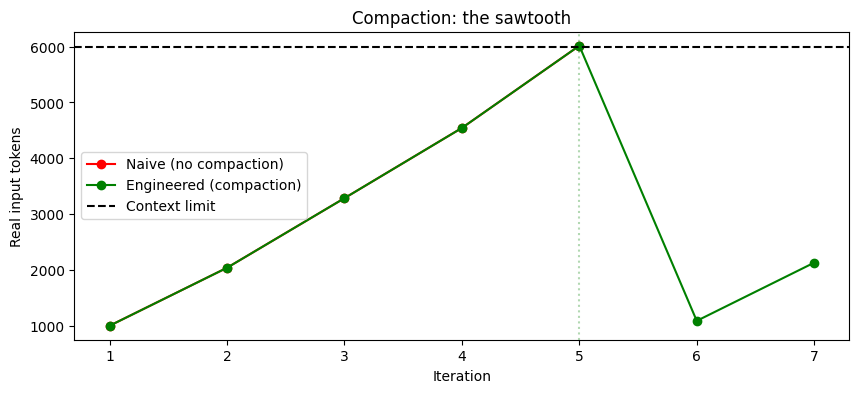

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(naive["tokens_per_iter"]) + 1), naive["tokens_per_iter"], "r-o", label="Naive (no compaction)")
plt.plot(range(1, len(eng["tokens_per_iter"]) + 1), eng["tokens_per_iter"], "g-o", label="Engineered (compaction)")
plt.axhline(MAX_TOKENS, color="black", linestyle="--", label="Context limit")
for ev in eng["compaction_events"]:
    plt.axvline(ev, color="green", alpha=0.3, linestyle=":")
plt.xlabel("Iteration"); plt.ylabel("Real input tokens")
plt.title("Compaction: the sawtooth")
plt.legend(); plt.show()

## What this experiment proved

1. Without compaction, history crosses the window limit and the task dies
   (red line hits the ceiling, run stops).
2. With compaction, tokens climb then DROP at each compaction event (the green
   sawtooth), staying under the limit -- and the task completes.
3. The recall-first summary preserved the running theme list, so continuity
   survived across the compaction boundary.

## Next experiment
Experiment 4 (External Memory): instead of summarizing INSIDE the window,
write notes OUTSIDE it -- so state survives even a full session reset.